In [1]:

from mri_loader import Subject, MRI
from nilearn.glm.first_level import FirstLevelModel

import pandas as pd
import numpy as np

from stats import *

from nilearn.reporting import get_clusters_table
from nilearn.glm import threshold_stats_img
from nilearn.plotting import plot_stat_map
from brain_map import find_region_names

from nilearn import datasets

import matplotlib.pyplot as plt



In [2]:
# for meet: maybe event time != process time

subject_ids = set(range(1, 34))
subject_ids -= {1, 3, 13, 22, 32, 33}  # fucked data

subject_ids = list(subject_ids)

run_ids = list(range(1,5))

print(subject_ids, run_ids)

[2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 23, 24, 25, 26, 27, 28, 29, 30, 31] [1, 2, 3, 4]


In [3]:

global_z_map = {}

contrast_list = [{"+": ["high"], "-": ["low"]},  # high > low
                 {"+": ["undecided"], "-": ["high", "low"]},]  # undecided > high + low

scale = [["25", "35"], ["35", "45"], ["45", "55"], ["55", "65"], ["65", "75"], ["75", "85"], ["85", "95"]]
to_subtract = {"-": ["5", "15"]}

for values in scale:
    contrast_list.append({
        "+": values,
        **to_subtract
    })

for classes in contrast_list:
    name = contrast_name(classes)
    global_z_map[name] = []

global_z_map

{'high > low': [],
 'undecided > high + low': [],
 '25 + 35 > 5 + 15': [],
 '35 + 45 > 5 + 15': [],
 '45 + 55 > 5 + 15': [],
 '55 + 65 > 5 + 15': [],
 '65 + 75 > 5 + 15': [],
 '75 + 85 > 5 + 15': [],
 '85 + 95 > 5 + 15': []}

In [7]:

from collections import defaultdict

skipped = []

for subject in subject_ids:

    try:
        dataset = Subject(subject, run_ids, confound_mode="full", volumes_offset=0)
        dataset.load()

        images, times, labels = dataset.get_data(morph_response=True)
        low_inflexion, high_inflexion = dataset.compute_inflexions()
    except Exception as e:
        print("Skipping subject ", subject)
        print(e)
        skipped.append(subject)
        continue

    print(f"{subject=} {low_inflexion=}, {high_inflexion=}")

    labels_class = set(labels)

    events = pd.DataFrame(
        {'onset': times,
         'trial_type': labels,
         'duration': 2.5}
    )

    repetition_time = dataset.repetition_time
    fmri_glm = FirstLevelModel(t_r=repetition_time,
              drift_model='polynomial',
              drift_order=3,
              smoothing_fwhm=8,
              hrf_model='spm',
              mask_img=dataset.brain_mask,
              n_jobs=-1)

    fmri_glm = fmri_glm.fit(images, events)

    design_matrix = fmri_glm.design_matrices_[0]

    contrast_matrix = np.eye(design_matrix.shape[1])
    contrasts = {
        str(column): contrast_matrix[i]
        for i, column in enumerate(design_matrix.columns)
    }

    low_contrast_columns = []
    high_contrast_columns = []
    undecided_contrast_columns = []

    morph_columns = defaultdict(list)

    for key, column in contrasts.items():
        try:
            key_numeric = float(key.split("_")[0]) / 100
            key_parsed = str(int(key_numeric * 100))
            morph_columns[key_parsed].append(column)

            if key_numeric < low_inflexion:
                low_contrast_columns.append(column)

            elif key_numeric > high_inflexion:
                high_contrast_columns.append(column)

            else:
                undecided_contrast_columns.append(column)

        except ValueError:
            continue

    contrasts["low"]       = np.sum(low_contrast_columns, axis=0)
    contrasts["high"]      = np.sum(high_contrast_columns, axis=0)
    contrasts["undecided"] = np.sum(undecided_contrast_columns, axis=0)

    for key, cols in morph_columns.items():
        contrasts[key] = np.sum(cols, axis=0)

    for contrast in contrast_list:
        print(contrast)

        glm_contrast_vector  = np.sum(contrasts[column] for column in contrast["+"])
        glm_contrast_vector -= np.sum(contrasts[column] for column in contrast["-"])

        print(glm_contrast_vector)
        z_score = fmri_glm.compute_contrast(glm_contrast_vector, output_type="z_score")
        name = contrast_name(contrast)

        global_z_map[name].append(z_score)




subject=2 low_inflexion=np.float64(0.2698198198198198), high_inflexion=np.float64(0.613063063063063)


OSError: [WinError 1450] Ressources système insuffisantes pour terminer le service demandé

In [ ]:
z_map_subjects = set(subject_ids)
z_map_subjects -= set(skipped)

plt.style.use('dark_background')

for contrast_name, images in global_z_map.items():
    for z_score, subject in zip(images, z_map_subjects):

        if False:

            clean_z, threshold = threshold_stats_img(z_score, alpha=0.001, height_control="fpr", cluster_threshold=5)
            cut_coords_list = [
                (0, 0, 0),
                (10, -20, 30),
                (-15, 10, 45),
            ]

            n_coords = len(cut_coords_list)

            fig, axes = plt.subplots(
                n_coords, 1,
                figsize=(15, 4 * n_coords)
            )

            fig.suptitle(contrast_name, fontweight="bold")

            bg_run = MRI(subject, 1)

            for ax, coords in zip(axes, cut_coords_list):
                plot_stat_map(
                    clean_z,
                    display_mode='ortho',
                    cut_coords=coords,
                    axes=ax,
                    bg_img=bg_run.background,
                    title=f"Ortho @ {coords}",
                    colorbar=True
                )

            plt.tight_layout()
            fname = contrast_name.replace(' ', '_').replace('>', 'over')
            plt.savefig(f"graphs/contrasts/sub-{subject}-contrast-{fname}.png")

In [32]:

atlas_name = 'cort-maxprob-thr0-1mm'
harvard = datasets.fetch_atlas_harvard_oxford(atlas_name=atlas_name)

atlas_img = harvard.maps
labels = harvard.labels

regions_activated = {}

for contrast_name, images in global_z_map.items():
    regions_activated[contrast_name] = []

    for z_score in images:

        clean, threshold = threshold_stats_img(z_score, alpha=0.001, height_control="fpr", cluster_threshold=5)
        table = get_clusters_table(
            clean, stat_threshold=threshold, cluster_threshold=5
        )

        pos = [(x,y,z) for (x,y,z) in zip(table['X'], table['Z'], table['Y'])]

        try:
            indexes, regions_names = find_region_names(pos, atlas_img, labels=labels)
        except Exception as e:
            print(e)
            continue

        regions_names = list(set(str(v) for v in regions_names))

        regions_activated[contrast_name].append(regions_names)

        print(f"{contrast_name=}, {regions_names=}")


[fetch_atlas_harvard_oxford] Dataset found in C:\Users\ducat\nilearn_data\fsl

contrast_name='high > low', regions_names=['Background', 'Frontal Pole', 'Temporal Pole']
contrast_name='high > low', regions_names=['Background', 'Frontal Pole', 'Temporal Pole']
contrast_name='high > low', regions_names=['Background', 'Frontal Pole']
contrast_name='high > low', regions_names=['Precentral Gyrus', 'Juxtapositional Lobule Cortex (formerly Supplementary Motor Cortex)', 'Subcallosal Cortex', 'Frontal Pole', 'Background', 'Middle Frontal Gyrus', 'Superior Frontal Gyrus', 'Middle Temporal Gyrus, anterior division', 'Paracingulate Gyrus']
contrast_name='high > low', regions_names=['Inferior Frontal Gyrus, pars opercularis', 'Precentral Gyrus', 'Insular Cortex', 'Frontal Pole', 'Subcallosal Cortex', 'Background', 'Central Opercular Cortex', 'Middle Frontal Gyrus', 'Middle Temporal Gyrus, posterior division', 'Superior Frontal Gyrus', 'Inferior Frontal Gyrus, pars triangularis', 'Postcentral Gyrus', 'Middle Temporal Gyrus, anterior division']
contrast_name='high > low', region

In [33]:
import pandas as pd



In [34]:

regions_activated_np = {}
regions_count = {}

for k, v in regions_activated.items():
    regions_activated_np[k] = np.array(v, dtype=object)

    regions_activated_np[k] = np.concatenate(regions_activated[k])

    regions_count[k] = np.unique_counts(regions_activated_np[k])

regions_count

{'high > low': UniqueCountsResult(values=array(['Background', 'Central Opercular Cortex',
        'Cingulate Gyrus, anterior division', 'Frontal Medial Cortex',
        'Frontal Orbital Cortex', 'Frontal Pole',
        "Heschl's Gyrus (includes H1 and H2)",
        'Inferior Frontal Gyrus, pars opercularis',
        'Inferior Frontal Gyrus, pars triangularis',
        'Inferior Temporal Gyrus, posterior division',
        'Inferior Temporal Gyrus, temporooccipital part', 'Insular Cortex',
        'Juxtapositional Lobule Cortex (formerly Supplementary Motor Cortex)',
        'Middle Frontal Gyrus', 'Middle Temporal Gyrus, anterior division',
        'Middle Temporal Gyrus, posterior division',
        'Middle Temporal Gyrus, temporooccipital part',
        'Paracingulate Gyrus', 'Parahippocampal Gyrus, anterior division',
        'Parahippocampal Gyrus, posterior division',
        'Parietal Opercular Cortex', 'Planum Polare', 'Postcentral Gyrus',
        'Precentral Gyrus', 'Subcallosa

In [35]:

df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in regions_activated_np.items()]))

for col in df.columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(6))


--- high > low ---
high > low
Background                26
Frontal Pole              15
Middle Frontal Gyrus      11
Superior Frontal Gyrus     8
Precentral Gyrus           7
Temporal Pole              6
Name: count, dtype: int64

--- undecided > high + low ---
undecided > high + low
Background                17
Frontal Pole              11
Superior Frontal Gyrus     9
Precentral Gyrus           8
Middle Frontal Gyrus       7
Temporal Pole              6
Name: count, dtype: int64

--- 25 + 35 > 5 + 15 ---
25 + 35 > 5 + 15
Background                23
Frontal Pole              16
Superior Frontal Gyrus    11
Middle Frontal Gyrus       9
Frontal Orbital Cortex     8
Temporal Pole              8
Name: count, dtype: int64

--- 35 + 45 > 5 + 15 ---
35 + 45 > 5 + 15
Background              22
Frontal Pole            15
Precentral Gyrus         9
Paracingulate Gyrus      9
Temporal Pole            8
Middle Frontal Gyrus     8
Name: count, dtype: int64

--- 45 + 55 > 5 + 15 ---
45 + 55 > 5 + 

In [36]:
summary = pd.DataFrame({
    col.replace(' ', ''): df[col].value_counts()
    for col in df.columns
})

summary = summary.fillna(0)

summary

,high>low,undecided>high+low,25+35>5+15,35+45>5+15,45+55>5+15,55+65>5+15,65+75>5+15,75+85>5+15,85+95>5+15
Background,26.0,17.0,23.0,22.0,24.0,23.0,23.0,24.0,25.0
Central Opercular Cortex,1.0,2.0,1.0,4.0,4.0,3.0,2.0,2.0,4.0
"Cingulate Gyrus, anterior division",1.0,1.0,3.0,4.0,5.0,7.0,7.0,4.0,2.0
Frontal Medial Cortex,1.0,1.0,2.0,4.0,4.0,1.0,4.0,1.0,1.0
Frontal Opercular Cortex,0.0,0.0,3.0,4.0,1.0,4.0,3.0,1.0,3.0
Frontal Orbital Cortex,6.0,3.0,8.0,5.0,7.0,4.0,8.0,7.0,5.0
Frontal Pole,15.0,11.0,16.0,15.0,16.0,17.0,20.0,17.0,19.0
Heschl's Gyrus (includes H1 and H2),1.0,0.0,2.0,0.0,0.0,2.0,0.0,0.0,0.0
"Inferior Frontal Gyrus, pars opercularis",2.0,3.0,3.0,5.0,7.0,8.0,8.0,2.0,4.0
"Inferior Frontal Gyrus, pars triangularis",5.0,3.0,2.0,4.0,5.0,4.0,9.0,5.0,5.0


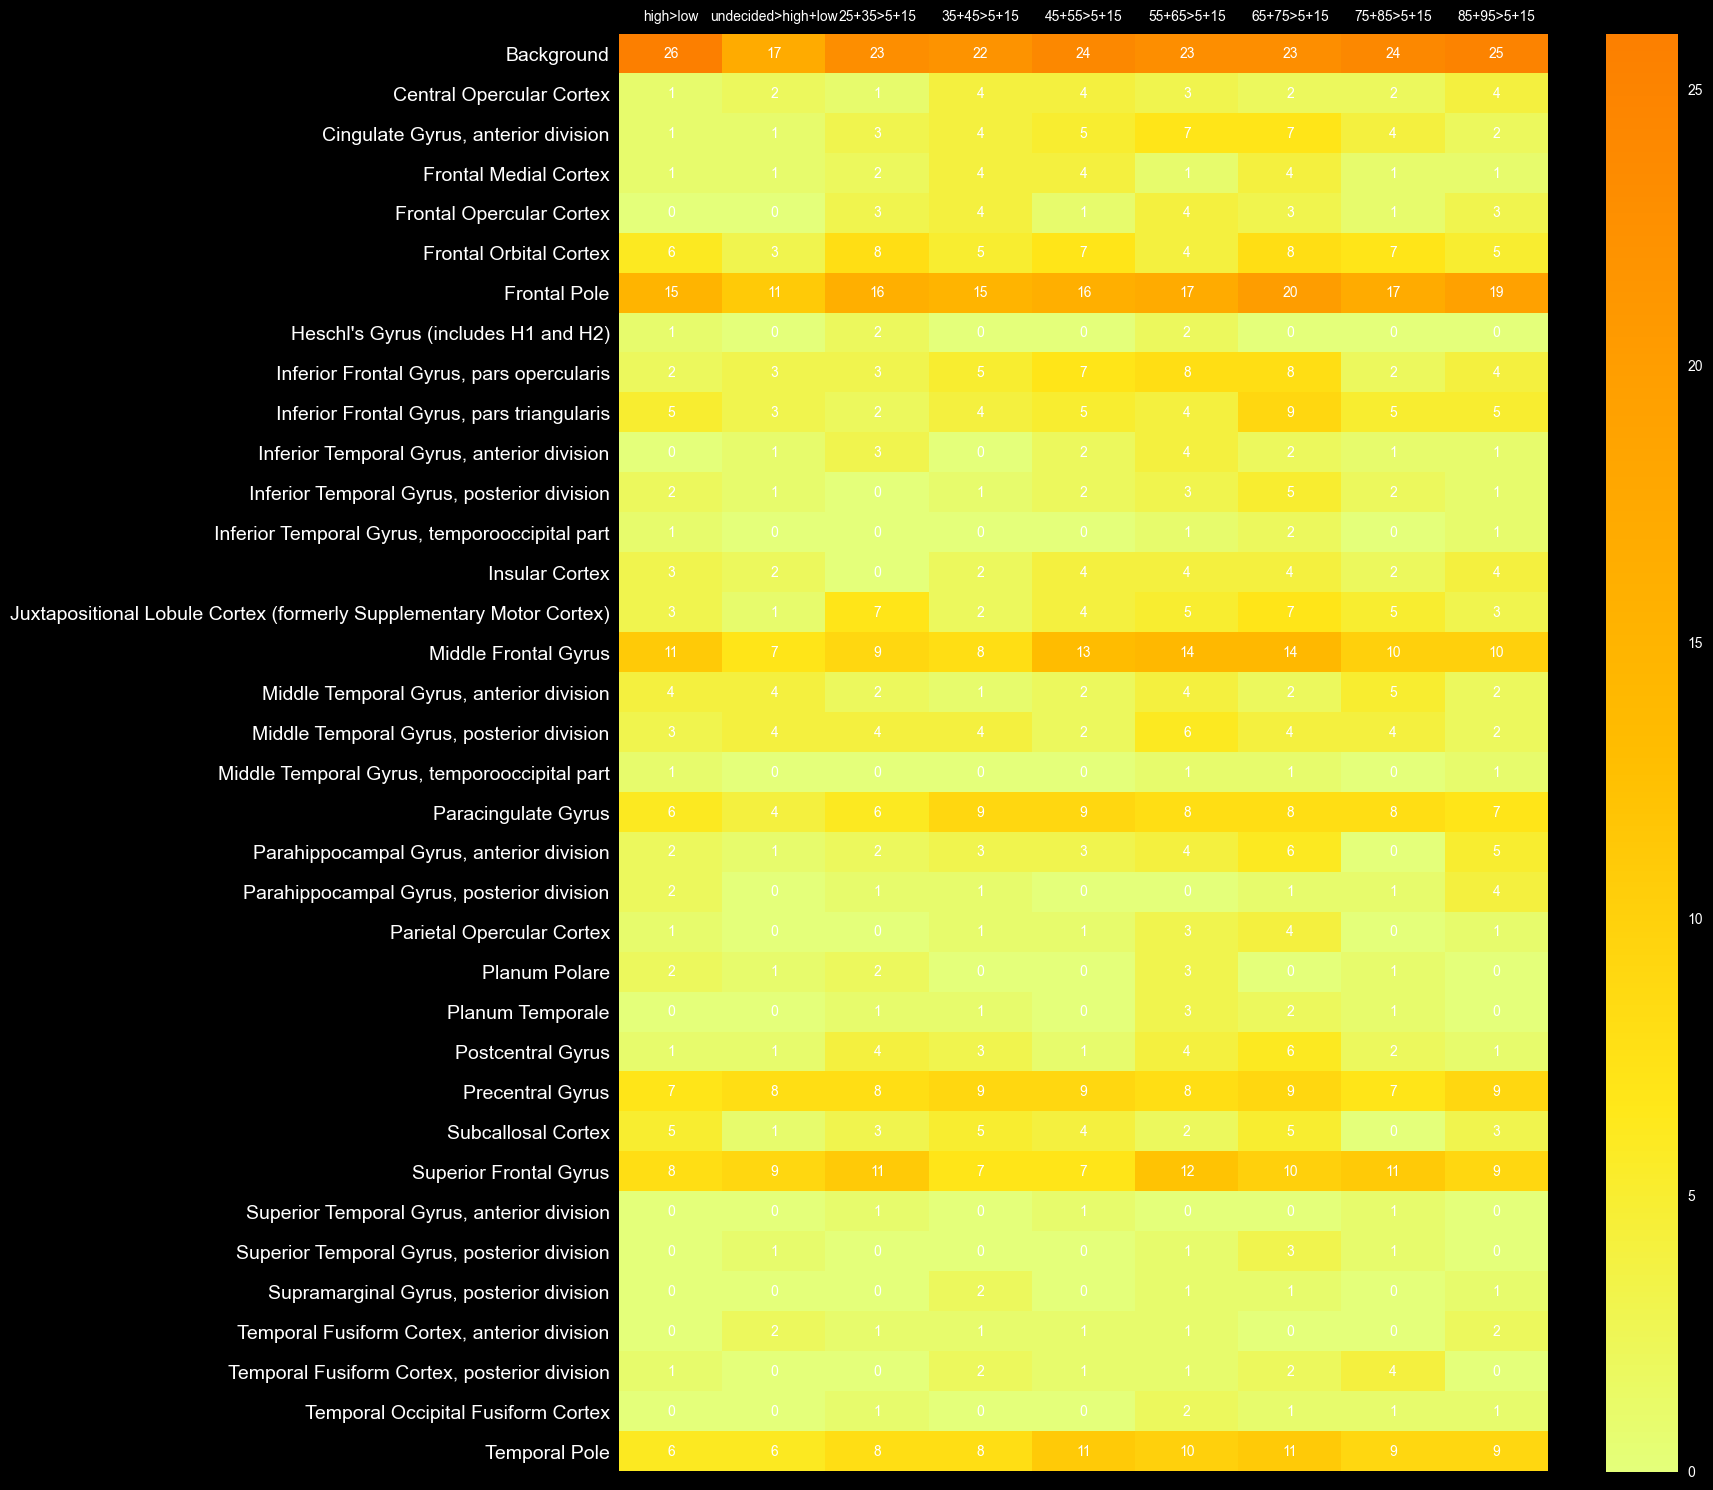

In [39]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(18, 15))
im = ax.imshow(summary.values, cmap='Wistia', aspect='auto')

ax.set_xticks(range(len(summary.columns)))
ax.set_yticks(range(len(summary)))
ax.set_xticklabels(summary.columns, fontsize=10)
ax.set_yticklabels(summary.index, fontsize=14)

ax.xaxis.tick_top()

for i in range(len(summary.index)):
    for j in range(len(summary.columns)):
        ax.text(j, i, f'{summary.values[i, j]:.0f}',
                ha='center', va='center', fontsize=10)

ax.grid(False)
ax.tick_params(which='both', length=0)

plt.colorbar(im)
plt.tight_layout()
plt.show()

In [38]:
summary.style.format("{:.0f}").background_gradient(cmap='Blues')

,high>low,undecided>high+low,25+35>5+15,35+45>5+15,45+55>5+15,55+65>5+15,65+75>5+15,75+85>5+15,85+95>5+15
Background,26,17,23,22,24,23,23,24,25
Central Opercular Cortex,1,2,1,4,4,3,2,2,4
"Cingulate Gyrus, anterior division",1,1,3,4,5,7,7,4,2
Frontal Medial Cortex,1,1,2,4,4,1,4,1,1
Frontal Opercular Cortex,0,0,3,4,1,4,3,1,3
Frontal Orbital Cortex,6,3,8,5,7,4,8,7,5
Frontal Pole,15,11,16,15,16,17,20,17,19
Heschl's Gyrus (includes H1 and H2),1,0,2,0,0,2,0,0,0
"Inferior Frontal Gyrus, pars opercularis",2,3,3,5,7,8,8,2,4
"Inferior Frontal Gyrus, pars triangularis",5,3,2,4,5,4,9,5,5


In [11]:
for contrast_name, images in global_z_map.items():
    for z_score in images:

        clean, threshold = threshold_stats_img(z_score, alpha=0.001, height_control="fpr", cluster_threshold=5)
        table = get_clusters_table(
            clean, stat_threshold=threshold, cluster_threshold=5
        )

        pos = [(x,y,z) for (x,y,z) in zip(table['X'], table['Z'], table['Y'])]

        print(pos)

        break

    break


[(-36.5, 4.299997806549072, -30.5), (-21.5, 61.899996280670166, -54.5), (-18.5, -42.500000953674316, -72.5), (29.5, 40.299996852874756, -54.5), (17.5, 40.299996852874756, 53.5), (35.5, 54.69999647140503, 23.5), (38.5, 58.2999963760376, 14.5), (26.5, 11.499997615814209, 2.5)]


In [37]:
from lib.mni_to_atlas import AtlasBrowser
import numpy as np

atlas = AtlasBrowser("AAL3")



In [38]:
mni_regions = {}

for contrast_name, images in global_z_map.items():
    mni_regions[contrast_name] = []
    print(contrast_name)

    for z_score in images:

        clean, threshold = threshold_stats_img(z_score, alpha=0.05, height_control="bonferroni", cluster_threshold=2)
        table = get_clusters_table(
            clean, stat_threshold=threshold, cluster_threshold=2
        )

        pos = [np.array([x,y,z]) for (x,y,z) in zip(table['X'], table['Z'], table['Y'])]

        for p in pos:
            projected_coords = atlas.project_to_nearest(p)
            projected_regions = atlas.find_regions(projected_coords)

            mni_regions[contrast_name].append(projected_regions)


high > low
undecided > high + low
25 + 35 > 5 + 15
35 + 45 > 5 + 15
45 + 55 > 5 + 15
55 + 65 > 5 + 15
65 + 75 > 5 + 15
75 + 85 > 5 + 15
85 + 95 > 5 + 15


In [39]:
mni_regions_concat = {}

for k, v in mni_regions.items():

    reg_list = np.array(v, dtype=object)

    mni_regions_concat[k] = np.concatenate(reg_list)

In [40]:
mni_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in mni_regions_concat.items()]))


In [41]:
mni_summary = pd.DataFrame({
    col.replace(' ', ''): mni_df[col].value_counts()
    for col in mni_df.columns
})

mni_summary = mni_summary.fillna(0)

mni_summary

,high>low,undecided>high+low,25+35>5+15,35+45>5+15,45+55>5+15,55+65>5+15,65+75>5+15,75+85>5+15,85+95>5+15
ACC_pre_L,0.0,1.0,2.0,3.0,0.0,1.0,2.0,0.0,1.0
ACC_pre_R,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
ACC_sub_L,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
ACC_sup_L,0.0,0.0,2.0,4.0,0.0,0.0,1.0,0.0,0.0
ACC_sup_R,0.0,1.0,1.0,2.0,0.0,1.0,0.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...
Temporal_Sup_L,0.0,0.0,0.0,1.0,1.0,3.0,0.0,1.0,0.0
Temporal_Sup_R,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,2.0
Vermis_3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
Vermis_8,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


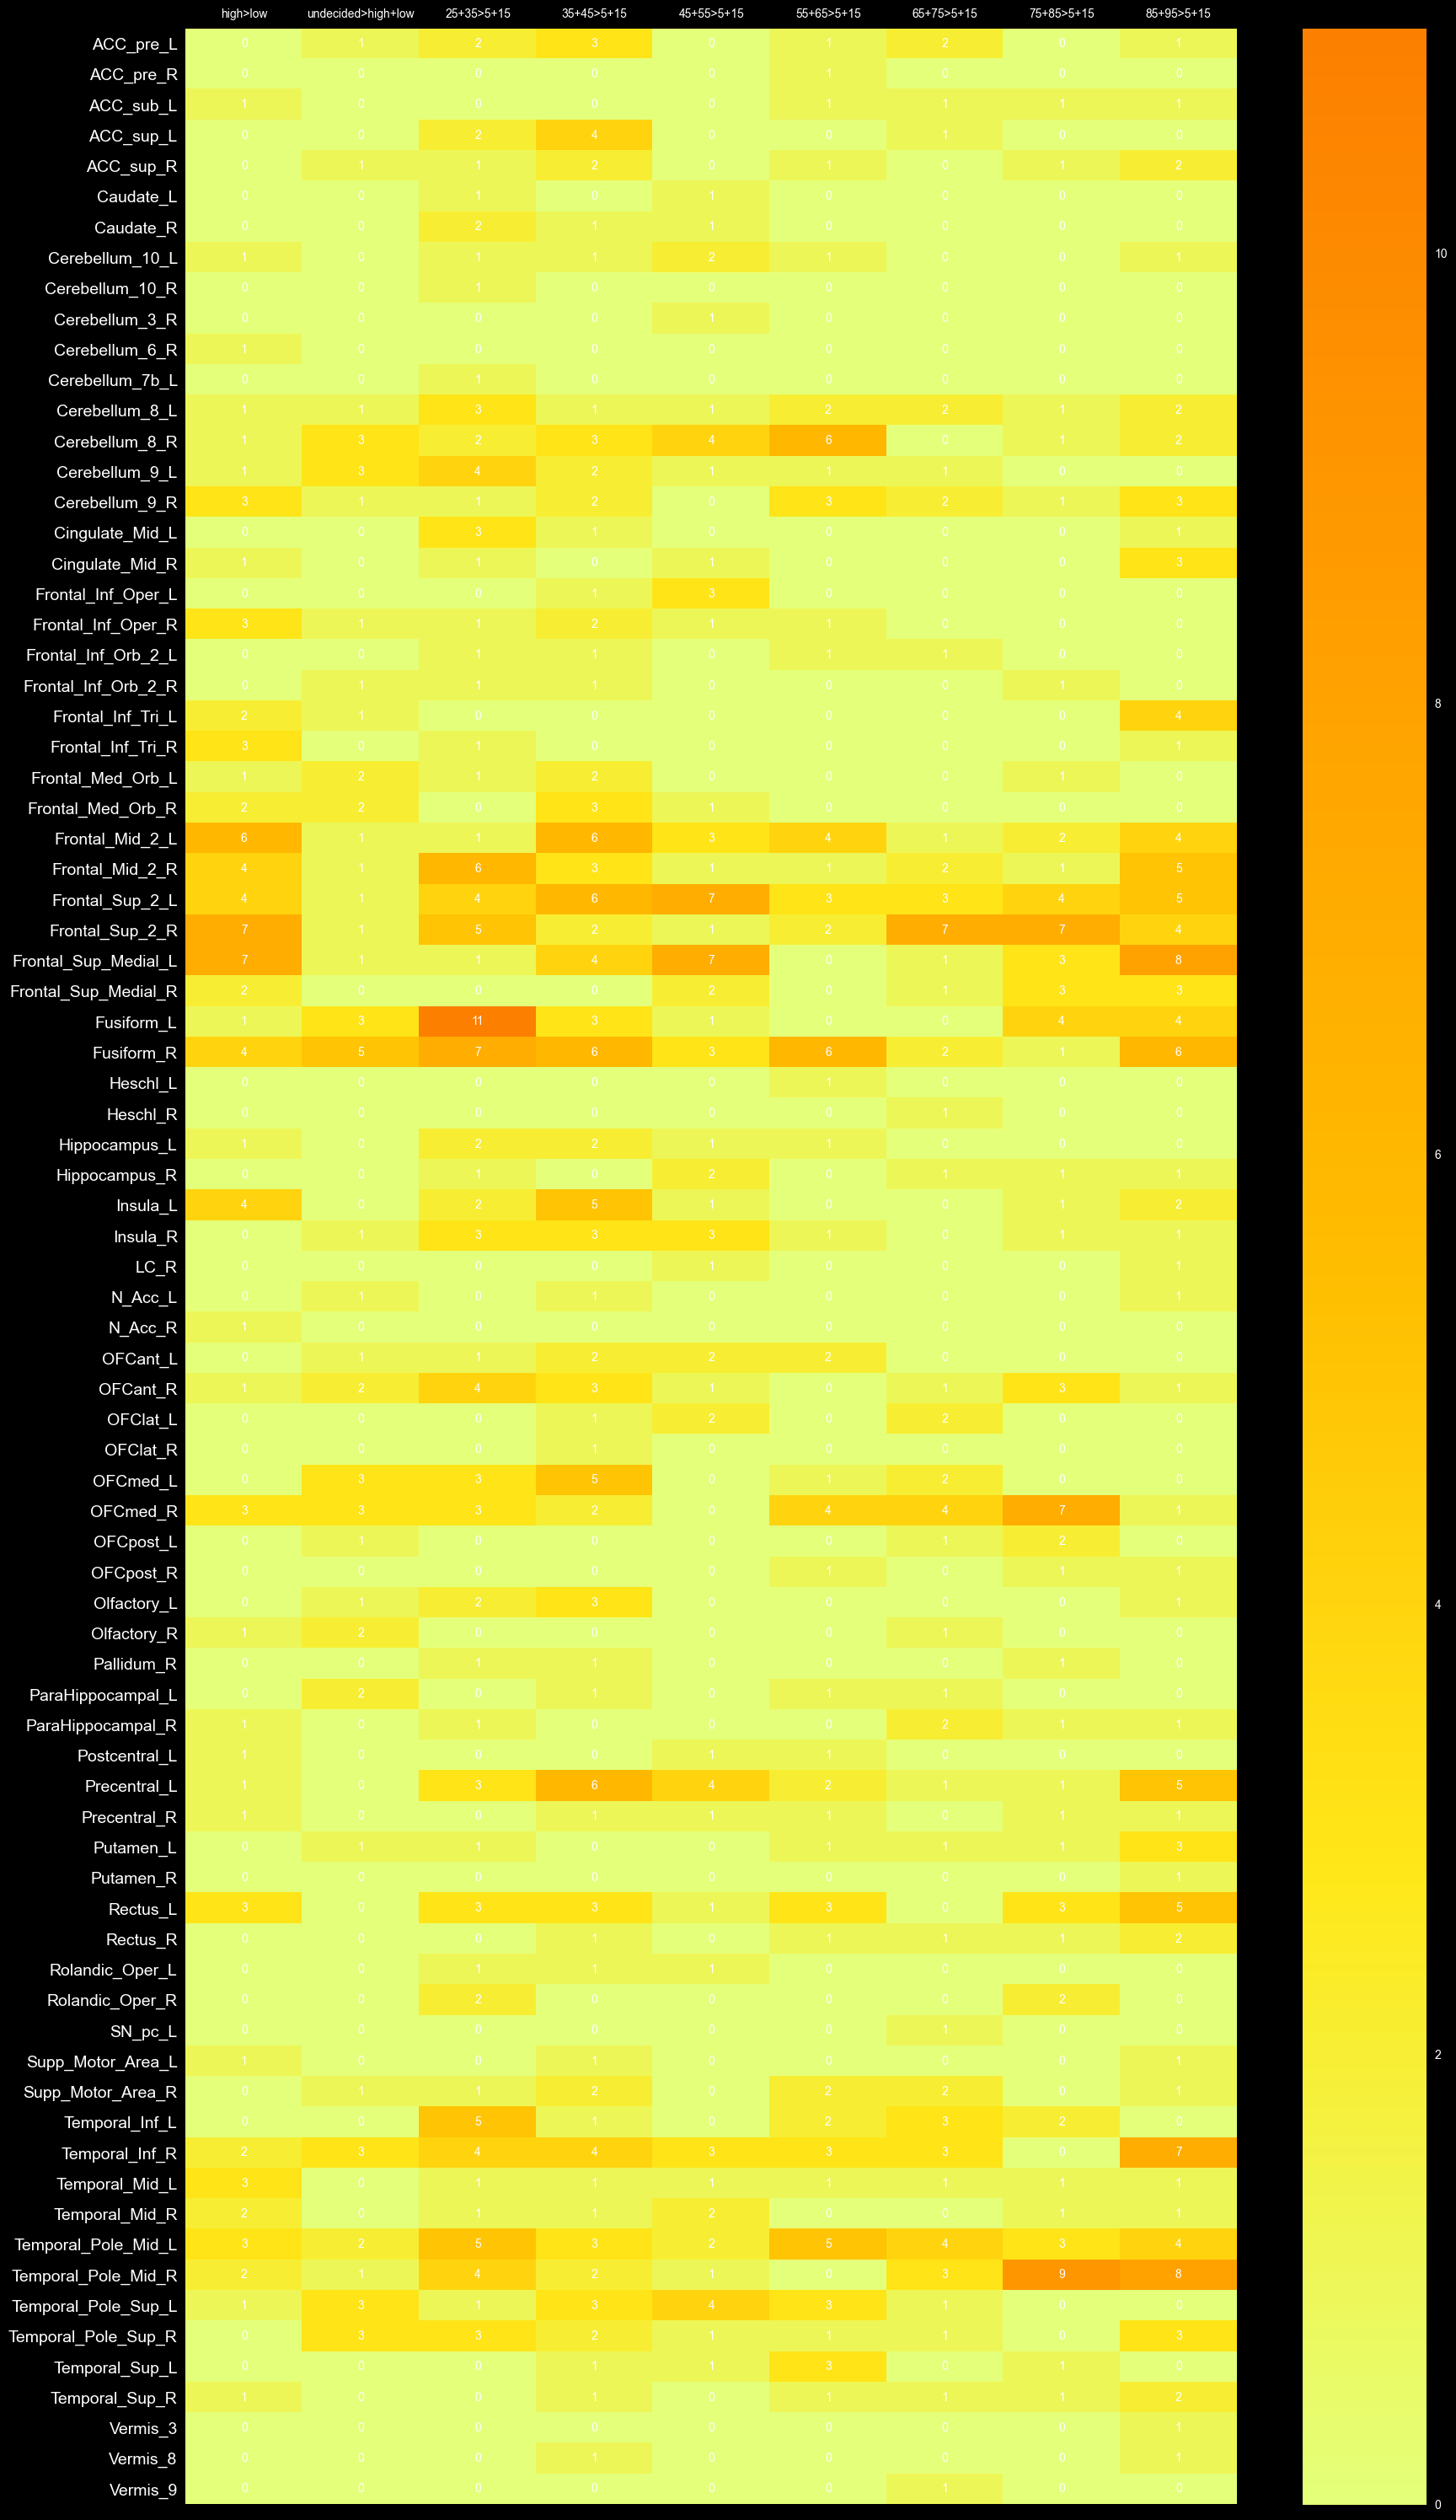

In [43]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(18, 30))
im = ax.imshow(mni_summary.values, cmap='Wistia', aspect='auto')

ax.set_xticks(range(len(mni_summary.columns)))
ax.set_yticks(range(len(mni_summary)))
ax.set_xticklabels(mni_summary.columns, fontsize=10)
ax.set_yticklabels(mni_summary.index, fontsize=14)

ax.xaxis.tick_top()

for i in range(len(mni_summary.index)):
    for j in range(len(mni_summary.columns)):
        ax.text(j, i, f'{mni_summary.values[i, j]:.0f}',
                ha='center', va='center', fontsize=10)

ax.grid(False)
ax.tick_params(which='both', length=0)

plt.colorbar(im)
plt.tight_layout()
plt.show()